# Original vs. LogReg Meta-Model Performance Distribution

Logistic Regression ensemble (EML) results only, comparing against original models for three datasets:
1. Qwen3-30B vs MetaCH
2. GPT-5 vs AlphaMissense
3. GDD-ENS vs GPT-5 (GENIE dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib import font_manager, rcParams
from scipy import stats
import seaborn as sns

# Font setup
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")
rcParams["font.family"] = "Liberation Sans"

# Color palette: Original LLM, Original task-specific, LogReg EML
PALETTE = {
    'llm':   '#4472C4',   # steel blue
    'task':  '#ED7D31',   # warm orange
    'meta':  '#70AD47',   # leaf green
}
ALPHA_BOX  = 0.25
ALPHA_DOT  = 0.55

plt.style.use('seaborn-v0_8-whitegrid')
rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.35,
    'grid.linestyle':     '--',
})

## Load Data

In [2]:
df1 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/mutation_meta_model_result/qwen3-30b_MetaCH_20260512_173044/10_fold_cv_detailed_results.csv')
df2 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/mutation_meta_model_result/gpt-5_AlphaMissense_10_fold_20251206_201157/10_fold_cv_detailed_results.csv')
df3 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/20251206_230739_gpt5_10fold/10_fold_cv_detailed_results.csv')

print(f"Dataset 1 (Qwen3-30B vs MetaCH):       {len(df1)} folds")
print(f"Dataset 2 (GPT-5 vs AlphaMissense):    {len(df2)} folds")
print(f"Dataset 3 (GDD-ENS vs GPT-5):          {len(df3)} folds")

Dataset 1 (Qwen3-30B vs MetaCH):       10 folds
Dataset 2 (GPT-5 vs AlphaMissense):    10 folds
Dataset 3 (GDD-ENS vs GPT-5):          10 folds


## Plotting Function

In [3]:
def logreg_boxplot_panel(
    ax, df,
    llm_col, task_col, logreg_col,
    llm_label, task_label, logreg_label,
    title, metric_name='Accuracy',
    show_legend=False, show_dots=True,
    y_label=None, ylim=None
):
    """
    Three-box panel: LLM original | task-specific original | LogReg EML.
    No mu labels; colored boxes; optional dot overlay.
    ylim: (ymin, ymax) in data units to override auto-computed limits.
    """
    cols   = [llm_col,  task_col,  logreg_col]
    labels = [llm_label, task_label, logreg_label]
    colors = [PALETTE['llm'], PALETTE['task'], PALETTE['meta']]

    data = [df[c].values for c in cols]

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        widths=0.52,
        showmeans=True,
        meanprops=dict(
            marker='D',
            markerfacecolor='white',
            markeredgecolor='crimson',
            markeredgewidth=1.8,
            markersize=9
        ),
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.8),
        flierprops=dict(marker='o', markersize=5, alpha=0.4),
        boxprops=dict(linewidth=2)
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(ALPHA_BOX + 0.55)
        patch.set_edgecolor(color)

    for w, color in zip(bp['whiskers'][0::2], colors):
        w.set_color(color)
    for w, color in zip(bp['whiskers'][1::2], colors):
        w.set_color(color)
    for c, color in zip(bp['caps'][0::2], colors):
        c.set_color(color)
    for c, color in zip(bp['caps'][1::2], colors):
        c.set_color(color)
    for f, color in zip(bp['fliers'], colors):
        f.set_markerfacecolor(color)
        f.set_markeredgecolor(color)

    if show_dots:
        for i, (vals, color) in enumerate(zip(data, colors)):
            xj = np.random.normal(0, 0.07, size=len(vals))
            ax.scatter(
                i + 1 + xj, vals,
                color=color, alpha=ALPHA_DOT,
                s=45, edgecolors='white', linewidth=0.6, zorder=3
            )

    # Improvement annotation below LogReg label
    improvement = ((df[logreg_col].mean() - df[task_col].mean()) / df[task_col].mean()) * 100
    sign = '+' if improvement >= 0 else ''
    ax.text(3, -0.09, f'({sign}{improvement:.1f}%)',
            ha='center', va='top', fontsize=17,
            color=PALETTE['meta'], fontweight='bold',
            transform=ax.get_xaxis_transform())

    # Y-axis limits
    all_vals = np.concatenate(data)
    if ylim is not None:
        ax.set_ylim(ylim[0], ylim[1])
    else:
        vmin, vmax = all_vals.min(), all_vals.max()
        pad = (vmax - vmin) * 0.12
        ax.set_ylim(vmin - pad, vmax + pad * 0.6)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))

    if metric_name == 'Accuracy':
        yticks = ax.get_yticks()
        ax.set_yticklabels([f"{int(round(y * 100))}" for y in yticks], fontsize=22)
    else:
        ax.tick_params(axis='y', labelsize=22)

    ylabel_text = y_label if y_label is not None else (
        'Accuracy (%)' if metric_name == 'Accuracy' else metric_name
    )
    if ylabel_text:
        ax.set_ylabel(ylabel_text, fontsize=24, fontweight='bold', labelpad=8)

    ax.set_title(title, fontsize=19, fontweight='bold', pad=12)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=19)

    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    if show_legend:
        legend_elements = [
            mpatches.Patch(facecolor=PALETTE['llm'],  edgecolor=PALETTE['llm'],  label='Original (LLM)',   alpha=0.8),
            mpatches.Patch(facecolor=PALETTE['task'], edgecolor=PALETTE['task'], label='Original (task)',  alpha=0.8),
            mpatches.Patch(facecolor=PALETTE['meta'], edgecolor=PALETTE['meta'], label='LogReg (EML)',     alpha=0.8),
            Line2D([0], [0], marker='D', color='w',
                   markerfacecolor='white', markeredgecolor='crimson',
                   markeredgewidth=1.8, markersize=9, label='Mean'),
            Line2D([0], [0], color='black', linewidth=2.5, label='Median'),
        ]
        ax.legend(handles=legend_elements, loc='lower right',
                  fontsize=14, framealpha=0.92, edgecolor='#cccccc')

    n_samples = len(df)
    ax.text(0.03, 0.02, f'n = {n_samples} folds',
            transform=ax.transAxes, fontsize=11,
            style='italic', color='#555555')

## Accuracy – Three Panels with Dots

/tmp/ipykernel_2802364/3512014136.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2802364/3512014136.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(round(y * 100))}" for y in yticks], fontsize=22)
/tmp/ipykernel_2802364/3512014136.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2802364/3512014136.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(round(y * 100))}" for y in yticks], fontsize=22)
/tmp/ipykernel_2802364/3512014136.py:20: Matplot

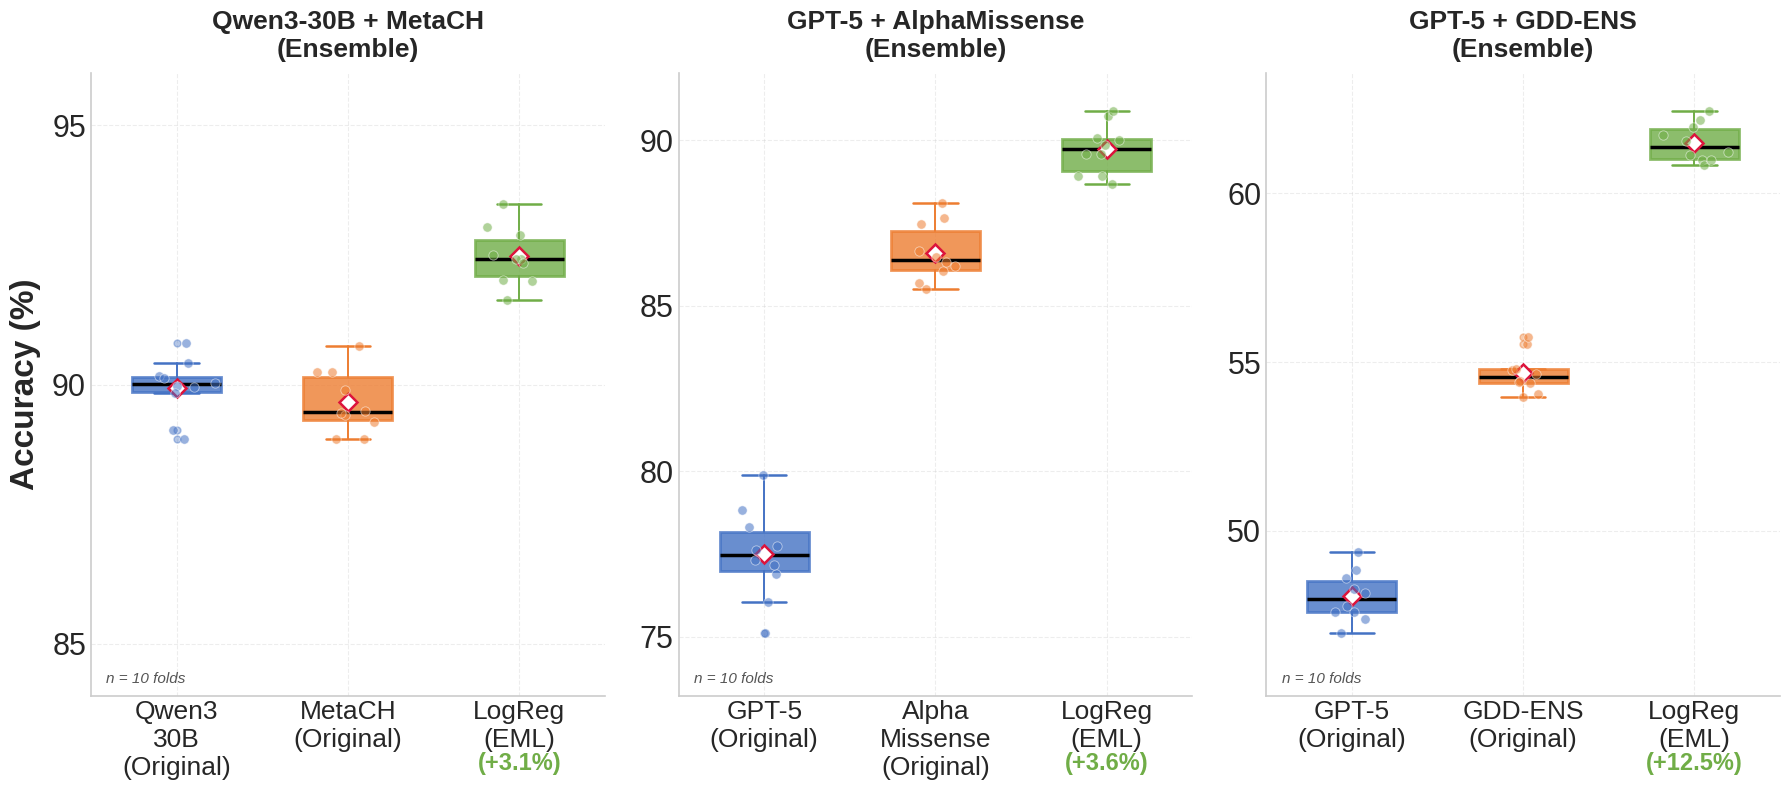

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

logreg_boxplot_panel(
    axes[0], df1,
    llm_col='qwen3-30b_accuracy', task_col='MetaCH_accuracy', logreg_col='LogReg_accuracy',
    llm_label='Qwen3\n30B\n(Original)', task_label='MetaCH\n(Original)', logreg_label='LogReg\n(EML)',
    title='Qwen3-30B + MetaCH\n(Ensemble)',
    metric_name='Accuracy', show_dots=True, ylim=(0.84, 0.96)
)

logreg_boxplot_panel(
    axes[1], df2,
    llm_col='gpt-5_accuracy', task_col='AlphaMissense_accuracy', logreg_col='LogReg_accuracy',
    llm_label='GPT-5\n(Original)', task_label='Alpha\nMissense\n(Original)', logreg_label='LogReg\n(EML)',
    title='GPT-5 + AlphaMissense\n(Ensemble)',
    metric_name='Accuracy', show_dots=True, y_label=''
)

logreg_boxplot_panel(
    axes[2], df3,
    llm_col='gpt_5_accuracy', task_col='GDD_accuracy', logreg_col='LogReg_accuracy',
    llm_label='GPT-5\n(Original)', task_label='GDD-ENS\n(Original)', logreg_label='LogReg\n(EML)',
    title='GPT-5 + GDD-ENS\n(Ensemble)',
    metric_name='Accuracy', show_dots=True, y_label=''
)

plt.tight_layout(w_pad=2.5)
plt.savefig('plots/logreg_meta_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/logreg_meta_model_accuracy.pdf', bbox_inches='tight')
plt.show()

## F1 Score – Three Panels with Dots

/tmp/ipykernel_2802364/3512014136.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2802364/3512014136.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2802364/3512014136.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


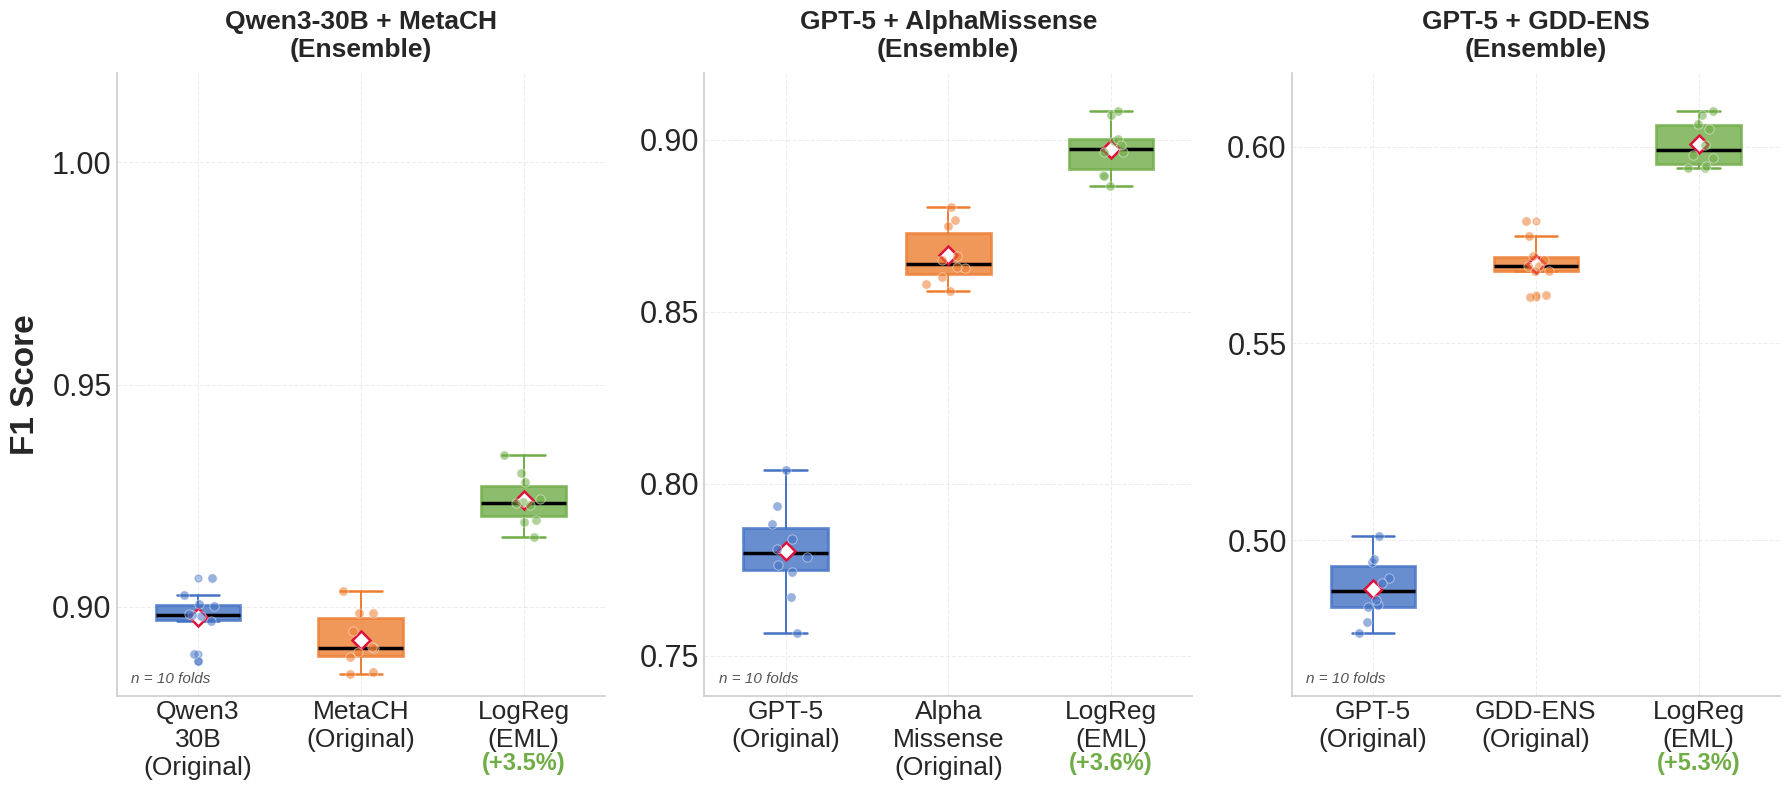

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

logreg_boxplot_panel(
    axes[0], df1,
    llm_col='qwen3-30b_f1', task_col='MetaCH_f1', logreg_col='LogReg_f1',
    llm_label='Qwen3\n30B\n(Original)', task_label='MetaCH\n(Original)', logreg_label='LogReg\n(EML)',
    title='Qwen3-30B + MetaCH\n(Ensemble)',
    metric_name='F1 Score', show_dots=True, ylim=(0.88, 0.96)
)

logreg_boxplot_panel(
    axes[1], df2,
    llm_col='gpt-5_f1', task_col='AlphaMissense_f1', logreg_col='LogReg_f1',
    llm_label='GPT-5\n(Original)', task_label='Alpha\nMissense\n(Original)', logreg_label='LogReg\n(EML)',
    title='GPT-5 + AlphaMissense\n(Ensemble)',
    metric_name='F1 Score', show_dots=True, y_label=''
)

logreg_boxplot_panel(
    axes[2], df3,
    llm_col='gpt_5_f1', task_col='GDD_f1', logreg_col='LogReg_f1',
    llm_label='GPT-5\n(Original)', task_label='GDD-ENS\n(Original)', logreg_label='LogReg\n(EML)',
    title='GPT-5 + GDD-ENS\n(Ensemble)',
    metric_name='F1 Score', show_dots=True, y_label=''
)

plt.tight_layout(w_pad=2.5)
plt.savefig('plots/logreg_meta_model_f1.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/logreg_meta_model_f1.pdf', bbox_inches='tight')
plt.show()

## GPT-5 + GDD-ENS LogReg Ensemble by Center (COLU vs DFCI)

In [6]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

mapping_df = pd.read_table("/data1/morrisq/yuj13/llm_genomics/GDD_ENS/data/tumor_type_final.txt")
mapping_df_first = mapping_df[['CANCER_TYPE', 'Cancer_Type']].drop_duplicates(subset='Cancer_Type', keep='first')
dot_to_readable = dict(zip(mapping_df_first['Cancer_Type'], mapping_df_first['CANCER_TYPE']))

gpt_retrained_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_20percent_filtered_out_gdd_gpt5_10fold_20260409_162651'
gpt_original_path  = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_20percent_filtered_out_gdd_gpt5_match_10fold_20260409_160218'
retrained_gddens   = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_20percent_filtered_out/GDD-ENS-retrained'
original_gddens    = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_20percent_filtered_out/GDD-ENS-original-retrained-match'

df_retrained = pd.read_csv(f'{gpt_retrained_path}/test_data/10_fold_cv_LogReg_test_data.csv')
df_original  = pd.read_csv(f'{gpt_original_path}/test_data/10_fold_cv_LogReg_test_data.csv')

for df_ in [df_retrained, df_original]:
    df_['center'] = df_['SAMPLE_ID'].apply(lambda x: 'COLU' if 'COLU' in x else 'DFCI')

def fold_metrics(df, center):
    rows = []
    sub = df[df['center'] == center]
    for fold in sub['fold'].unique():
        fd = sub[sub['fold'] == fold]
        rows.append({
            'fold':     fold,
            'accuracy': accuracy_score(fd['ground_truth'], fd['ensemble_prediction']),
            'f1':       f1_score(fd['ground_truth'], fd['ensemble_prediction'], average='weighted'),
        })
    return pd.DataFrame(rows)

mc_colu = fold_metrics(df_retrained, 'COLU')
mc_dfci = fold_metrics(df_retrained, 'DFCI')
mo_colu = fold_metrics(df_original,  'COLU')
mo_dfci = fold_metrics(df_original,  'DFCI')

# Standalone GDD-ENS metrics
gdd_r_colu = pd.read_csv(f'{retrained_gddens}/ensemble_allprobs_colu_anno.csv')
gdd_r_dfci = pd.read_csv(f'{retrained_gddens}/ensemble_allprobs_dfci_anno.csv')
gdd_o_colu = pd.read_csv(f'{original_gddens}/filtered_colu_match.csv')
gdd_o_dfci = pd.read_csv(f'{original_gddens}/filtered_dfci_match.csv')

for df_ in [gdd_o_colu, gdd_o_dfci]:
    df_['pred_mapped'] = df_['Pred1'].map(dot_to_readable).fillna(df_['Pred1'])

standalone = {
    'retrained': {
        'COLU': {'accuracy': accuracy_score(gdd_r_colu['target_name'], gdd_r_colu['inference_name']),
                 'f1':       f1_score(gdd_r_colu['target_name'], gdd_r_colu['inference_name'], average='weighted')},
        'DFCI': {'accuracy': accuracy_score(gdd_r_dfci['target_name'], gdd_r_dfci['inference_name']),
                 'f1':       f1_score(gdd_r_dfci['target_name'], gdd_r_dfci['inference_name'], average='weighted')},
    },
    'original': {
        'COLU': {'accuracy': accuracy_score(gdd_o_colu['Cancer_Type'], gdd_o_colu['pred_mapped']),
                 'f1':       f1_score(gdd_o_colu['Cancer_Type'], gdd_o_colu['pred_mapped'], average='weighted')},
        'DFCI': {'accuracy': accuracy_score(gdd_o_dfci['Cancer_Type'], gdd_o_dfci['pred_mapped']),
                 'f1':       f1_score(gdd_o_dfci['Cancer_Type'], gdd_o_dfci['pred_mapped'], average='weighted')},
    },
}

print('Standalone GDD-ENS metrics loaded.')

Standalone GDD-ENS metrics loaded.


/tmp/ipykernel_2802364/3712994741.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(round(y * 100))}" for y in yticks], fontsize=22)


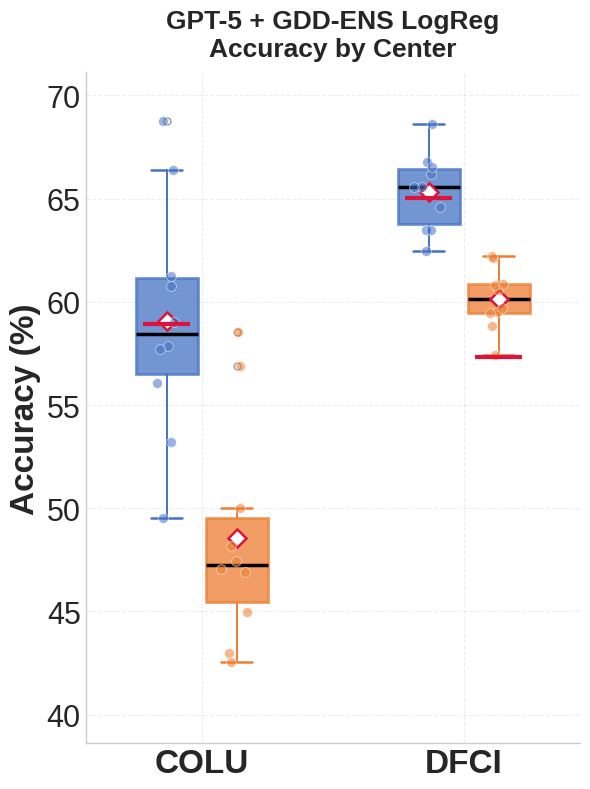

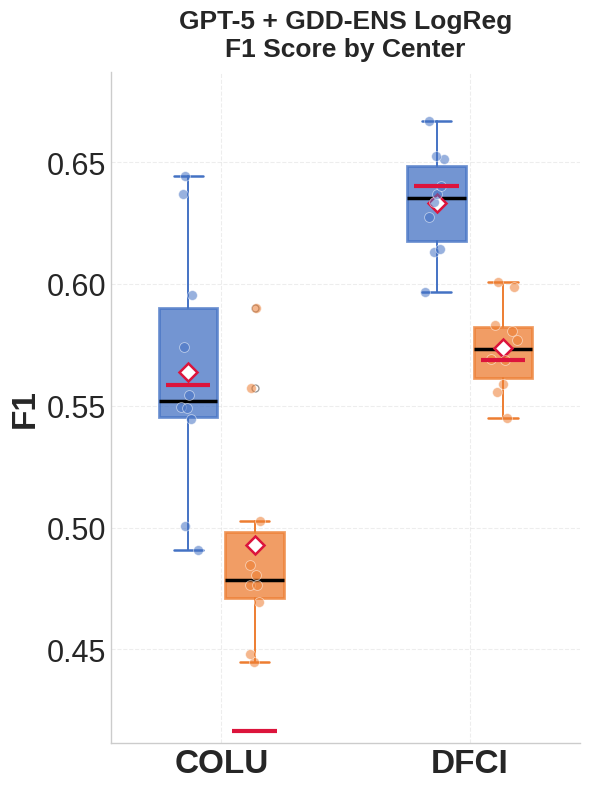

Saved center comparison figures.


In [7]:
def center_comparison_plot(metrics_by_center, center_names, model_names, model_colors,
                            standalone, metric_type='accuracy', figsize=(7, 8), title=None,
                            show_legend=False):
    """
    Grouped boxplot by center, colored boxes, dot overlay, no mu labels.
    standalone: dict[center][model_idx] -> scalar value for GDD-ENS standalone marker.
    """
    fig, ax = plt.subplots(figsize=figsize)

    n_models  = len(model_names)
    box_w     = 0.38
    intra_gap = 0.05
    group_gap = 0.80
    jitter_sd = 0.04

    all_positions, all_data, all_colors = [], [], []
    tick_positions = []

    for ci, center in enumerate(center_names):
        group_start = ci * (n_models * box_w + (n_models - 1) * intra_gap + group_gap)
        cpos = []
        for mi in range(n_models):
            pos = group_start + mi * (box_w + intra_gap)
            cpos.append(pos)
            all_positions.append(pos)
            all_data.append(metrics_by_center[ci][mi][metric_type].values)
            all_colors.append(model_colors[mi])
        tick_positions.append(np.mean(cpos))

    bp = ax.boxplot(
        all_data,
        positions=all_positions,
        widths=box_w,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='crimson', markeredgewidth=1.8, markersize=9),
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.8),
        flierprops=dict(marker='o', markersize=5, alpha=0.4),
        boxprops=dict(linewidth=2)
    )

    for patch, color in zip(bp['boxes'], all_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.75)

    for i, (w, color) in enumerate(zip(bp['whiskers'], [c for c in all_colors for _ in range(2)])):
        w.set_color(color)
    for i, (c, color) in enumerate(zip(bp['caps'], [c for c in all_colors for _ in range(2)])):
        c.set_color(color)

    for pos, vals, color in zip(all_positions, all_data, all_colors):
        xj = np.random.normal(0, jitter_sd, size=len(vals))
        ax.scatter(pos + xj, vals, color=color, alpha=ALPHA_DOT,
                   s=50, edgecolors='white', linewidth=0.6, zorder=3)

    # Standalone GDD-ENS markers
    for ci, center in enumerate(center_names):
        group_start = ci * (n_models * box_w + (n_models - 1) * intra_gap + group_gap)
        for mi in range(n_models):
            pos = group_start + mi * (box_w + intra_gap)
            if center in standalone and mi in standalone[center]:
                val = standalone[center][mi]
                ax.hlines(val, pos - box_w * 0.38, pos + box_w * 0.38,
                          colors='crimson', linewidth=3, zorder=4)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(center_names, fontsize=24, fontweight='bold')

    all_vals = np.concatenate(all_data)
    vmin, vmax = all_vals.min(), all_vals.max()
    pad = (vmax - vmin) * 0.15
    ax.set_ylim(vmin - pad, vmax + pad * 0.6)

    if metric_type == 'accuracy':
        ax.set_ylabel('Accuracy (%)', fontsize=24, fontweight='bold')
        yticks = ax.get_yticks()
        ax.set_yticklabels([f"{int(round(y * 100))}" for y in yticks], fontsize=22)
    else:
        ax.set_ylabel(metric_type.capitalize(), fontsize=24, fontweight='bold')
        ax.tick_params(axis='y', labelsize=22)

    if title:
        ax.set_title(title, fontsize=19, fontweight='bold', pad=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        legend_elements = [
            mpatches.Patch(facecolor=model_colors[mi], edgecolor=model_colors[mi],
                           label=model_names[mi], alpha=0.85)
            for mi in range(n_models)
        ]
        legend_elements += [
            Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
                   markeredgecolor='crimson', markeredgewidth=1.8, markersize=9, label='Mean'),
            Line2D([0], [0], color='crimson', linewidth=3, label='GDD-ENS Standalone'),
        ]
        ax.legend(handles=legend_elements, loc='lower right',
                  fontsize=12, framealpha=0.92, edgecolor='#cccccc')

    plt.tight_layout()
    return fig, ax


center_names  = ['COLU', 'DFCI']
model_names   = ['GPT-5 +\nRetrained GDD-ENS', 'GPT-5 +\nOriginal GDD-ENS']
model_colors  = [PALETTE['llm'], PALETTE['task']]

metrics_by_center = [
    [mc_colu, mo_colu],
    [mc_dfci, mo_dfci],
]

standalone_acc = {
    'COLU': {0: standalone['retrained']['COLU']['accuracy'],
             1: standalone['original']['COLU']['accuracy']},
    'DFCI': {0: standalone['retrained']['DFCI']['accuracy'],
             1: standalone['original']['DFCI']['accuracy']},
}
standalone_f1 = {
    'COLU': {0: standalone['retrained']['COLU']['f1'],
             1: standalone['original']['COLU']['f1']},
    'DFCI': {0: standalone['retrained']['DFCI']['f1'],
             1: standalone['original']['DFCI']['f1']},
}

fig_acc_center, _ = center_comparison_plot(
    metrics_by_center, center_names, model_names, model_colors,
    standalone_acc, metric_type='accuracy', figsize=(6, 8),
    title='GPT-5 + GDD-ENS LogReg\nAccuracy by Center'
)
fig_acc_center.savefig('plots/logreg_gpt5_gdd_center_accuracy.png', dpi=300, bbox_inches='tight')
fig_acc_center.savefig('plots/logreg_gpt5_gdd_center_accuracy.pdf', bbox_inches='tight')
plt.show()

fig_f1_center, _ = center_comparison_plot(
    metrics_by_center, center_names, model_names, model_colors,
    standalone_f1, metric_type='f1', figsize=(6, 8),
    title='GPT-5 + GDD-ENS LogReg\nF1 Score by Center'
)
fig_f1_center.savefig('plots/logreg_gpt5_gdd_center_f1.png', dpi=300, bbox_inches='tight')
fig_f1_center.savefig('plots/logreg_gpt5_gdd_center_f1.pdf', bbox_inches='tight')
plt.show()

print('Saved center comparison figures.')